# 机器学习实验二：基于 PyTorch 的手写数字识别

这份 notebook 分为两部分：

1. **基线示例**  
   前半部分提供一个完整可运行的基线模型，包含数据加载、数据预处理、模型构建、训练、验证、测试和曲线绘制等流程。  
   请先完整运行这一部分，理解深度学习实验的基本流程。

2. **学生实验模板**  
   后半部分用于完成调参与对比实验。  
   请参考基线示例，在指定位置修改参数、补充代码、运行实验，并记录结果。

使用建议：

- 先从上到下运行基线示例，确认环境和代码可以正常运行。
- 再阅读封装好的训练与评估函数，理解它们在后续实验中的作用。
- 最后完成 batch size、隐藏层层数、神经元数量、激活函数和 Dropout 等单变量对比实验。
- 附加题为选做内容，可根据兴趣和时间完成。

## 一、基线示例

目标：先跑通一个最简单的全连接 BP 神经网络。

流程：数据加载 → 数据预处理 → 模型构建 → 训练 → 验证 → 测试。


### 1. 导入库并设置设备


In [2]:
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt


# 固定随机种子，方便复现实验结果。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# 有 GPU 就使用 GPU，否则使用 CPU。
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)


使用设备: cpu


### 2. 数据预处理

`ToTensor()` 会把图片像素从 0 ~ 255 转成 0 ~ 1。  
这是因为神经网络更适合处理数值范围较小的数据，先缩放可以让训练更稳定。

`Normalize()` 会进一步做标准化，让数据分布更合适。  
标准化后，数据不再局限于 0 ~ 1，而是变成“减去均值，再除以标准差”后的结果。这样通常有助于模型更快收敛，也能让不同维度的数据处于更接近的尺度上。

可以**简单理解**为：

- `ToTensor()`：先把数值变小
- `Normalize()`：再把数据调整得更适合训练

In [3]:
# MNIST 是 1 通道灰度图，所以均值和标准差都只有一个数。
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),                         # 0~255 -> 0~1
    transforms.Normalize(MNIST_MEAN, MNIST_STD),   # 标准化
])


### 3. 加载数据集并划分验证集

原始 MNIST 训练集有 60000 张图片。

这里划分为：

- 50000 张：训练集，用来更新模型参数
- 10000 张：验证集，用来调参和画曲线

测试集保留到最后使用。


In [4]:
# 下载并读取 MNIST 数据集。
train_full = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

TRAIN_SIZE = 50000   # 用于训练
VAL_SIZE = 10000     # 用于调参与画曲线

# 使用固定随机种子划分，保证每次运行划分结果一致。
train_dataset, val_dataset = random_split(
    train_full,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("测试集样本数:", len(test_dataset))


训练集样本数: 50000
验证集样本数: 10000
测试集样本数: 10000


### 4. 设置基线参数

下面这组参数用于设置**基线实验**。  
建议先使用这组参数完整运行一次，得到基线结果，作为后续对比实验的参照。

基线模型结构为：

`Flatten → Linear(784, 128) → ReLU → Linear(128, 10)`


In [5]:
# 基线参数：不建议修改。
batch_size = 64
hidden_dim = 128
learning_rate = 0.001
epochs = 5


### 5. 创建 DataLoader

DataLoader 负责把数据按 batch 送入模型。


In [6]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("每个 batch 的样本数:", batch_size)
print("训练集 batch 数量:", len(train_loader))


每个 batch 的样本数: 64
训练集 batch 数量: 782


### 6. 搭建基线 BP 神经网络模型

注意：本实验使用 `nn.CrossEntropyLoss()`，模型最后一层直接输出 logits，不需要加 `Softmax`。


In [7]:
baseline_model = nn.Sequential(
    nn.Flatten(),                 # [batch_size, 1, 28, 28] -> [batch_size, 784]
    nn.Linear(784, hidden_dim),    # 第 1 个全连接层
    nn.ReLU(),                    # 激活函数
    nn.Linear(hidden_dim, 10),     # 输出层：10 类数字
).to(device)

print(baseline_model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### 7. 训练并验证基线模型

下面这段代码是最直观的训练流程。  
每个 epoch 包括：

1. 在训练集上训练模型
2. 在验证集上评估模型
3. 保存并打印本轮的 loss、accuracy 和耗时


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

# 用 history 保存每个 epoch 的结果，后面用于打印表格和画曲线。
baseline_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # ========== 训练阶段 ==========
    baseline_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        # 1. 清空上一轮梯度，避免梯度累积
        optimizer.zero_grad()

        # 2. 前向传播，得到模型输出
        output = baseline_model(data)

        # 3. 计算损失
        loss = criterion(output, target)

        # 4. 反向传播并更新参数
        loss.backward()
        optimizer.step()

        # 5. 统计本 batch 的 loss 和准确率
        train_loss_sum += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        train_correct += (pred == target).sum().item()
        train_total += target.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = 100 * train_correct / train_total

    # ========== 验证阶段 ==========
    baseline_model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = baseline_model(data)
            loss = criterion(output, target)

            val_loss_sum += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            val_correct += (pred == target).sum().item()
            val_total += target.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time

    # ========== 保存结果 ==========
    baseline_history["epoch"].append(epoch)
    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    baseline_history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
        f"time={epoch_time:.2f}s"
    )

print(f"训练总耗时: {sum(baseline_history['epoch_time']):.2f} 秒")


Epoch 01/5 | train_loss=0.2786, train_acc=91.80% | val_loss=0.1581, val_acc=95.25% | time=8.44s
Epoch 02/5 | train_loss=0.1183, train_acc=96.56% | val_loss=0.1250, val_acc=96.19% | time=11.15s
Epoch 03/5 | train_loss=0.0814, train_acc=97.55% | val_loss=0.1149, val_acc=96.55% | time=6.80s
Epoch 04/5 | train_loss=0.0613, train_acc=98.08% | val_loss=0.0956, val_acc=97.07% | time=6.38s
Epoch 05/5 | train_loss=0.0471, train_acc=98.51% | val_loss=0.0886, val_acc=97.35% | time=5.81s
训练总耗时: 38.58 秒


### 8. 查看基线实验结果

报告截图建议包含：

- 每个 epoch 的输出
- 最后 3 个 epoch 的表格
- loss 曲线和 accuracy 曲线


In [9]:
print("最后 3 个 epoch 结果：")

header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
print(header)
print("-" * len(header))

start = max(0, len(baseline_history["epoch"]) - 3)
for i in range(start, len(baseline_history["epoch"])):
    print(
        f"{baseline_history['epoch'][i]:>5} | "
        f"{baseline_history['train_loss'][i]:>10.4f} | "
        f"{baseline_history['train_acc'][i]:>8.2f}% | "
        f"{baseline_history['val_loss'][i]:>8.4f} | "
        f"{baseline_history['val_acc'][i]:>6.2f}% | "
        f"{baseline_history['epoch_time'][i]:>7.2f}"
    )


最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.55% |   0.1149 |  96.55% |    6.80
    4 |     0.0613 |    98.08% |   0.0956 |  97.07% |    6.38
    5 |     0.0471 |    98.51% |   0.0886 |  97.35% |    5.81


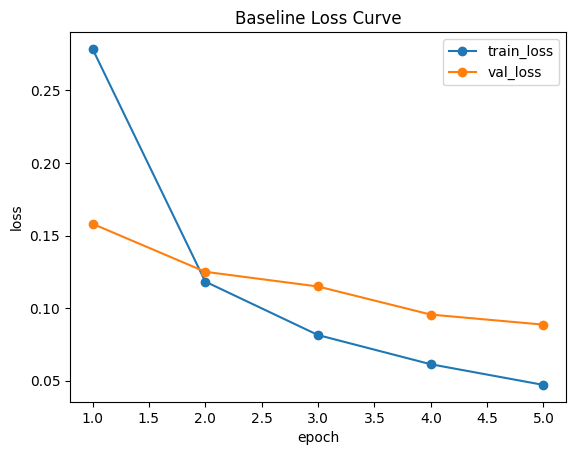

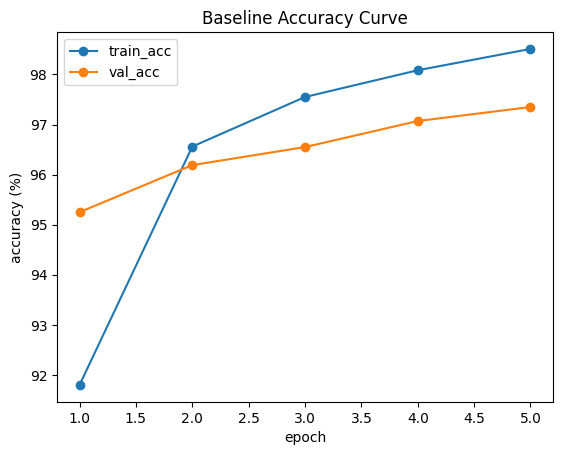

In [10]:
# 绘制 loss 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_loss"], marker="o", label="train_loss")
plt.plot(baseline_history["epoch"], baseline_history["val_loss"], marker="o", label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Baseline Loss Curve")
plt.legend()
plt.show()

# 绘制 accuracy 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_acc"], marker="o", label="train_acc")
plt.plot(baseline_history["epoch"], baseline_history["val_acc"], marker="o", label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Baseline Accuracy Curve")
plt.legend()
plt.show()


### 9. 在测试集上评估基线模型

调参阶段主要看验证集。  
测试集建议只在基线模型或最终选定模型上评估。


In [11]:
baseline_model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = baseline_model(data)
        loss = criterion(output, target)

        test_loss_sum += loss.item() * data.size(0)

        pred = output.argmax(dim=1)

        test_correct += (pred == target).sum().item()
        test_total += target.size(0)

        all_targets.extend(target.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())

baseline_test_loss = test_loss_sum / test_total
baseline_test_acc = 100 * test_correct / test_total

baseline_test_precision = precision_score(all_targets, all_preds, average='macro')
baseline_test_recall = recall_score(all_targets, all_preds, average='macro')
baseline_test_f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_acc:.2f}%")
print(f"Baseline test precision (macro): {baseline_test_precision:.4f}")
print(f"Baseline test recall (macro): {baseline_test_recall:.4f}")
print(f"Baseline test f1-score (macro): {baseline_test_f1:.4f}")


Baseline test loss: 0.0806
Baseline test accuracy: 97.59%
Baseline test precision (macro): 0.9758
Baseline test recall (macro): 0.9758
Baseline test f1-score (macro): 0.9758


## 二、为了方便后续**调参**实验，封装统一实验函数

前面已经用较为直观的方式完成了一次基线实验，便于理解完整训练流程。  
为了让后续调参与对比实验更方便、代码更简洁，下面将基线实验的主要流程整理成统一实验函数 `run_experiment(...)`。

从后面的实验开始，学生主要通过**修改调用 `run_experiment(...)` 时传入的参数**来完成不同调参对比实验。


### 10. 准备几个辅助函数

下面这些函数只是把前面基线代码中的重复部分整理出来。  
一般**不需要修改**这些函数，理解它们的作用即可。


In [12]:
def set_seed(seed=SEED):
    """固定随机种子，尽量减少实验中的随机因素。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_dataloaders(batch_size):
    """根据 batch_size 创建训练集、验证集和测试集 DataLoader。"""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def get_activation(name):
    """根据名称返回激活函数。"""
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    if name == "leaky_relu":
        return nn.LeakyReLU()

    raise ValueError("activation_name 只能是 relu / sigmoid / tanh / leaky_relu")


def build_mlp(hidden_dims=None, activation_name="relu", dropout_p=0.0):
    """
    构建全连接 BP 神经网络。

    参数说明：
    - hidden_dims: 隐藏层神经元数量列表，例如 [128]、[128, 128, 128]
    - activation_name: 激活函数名称
    - dropout_p: Dropout 概率，0.0 表示不使用 Dropout
    """
    if hidden_dims is None:
        hidden_dims = [128]

    layers = [nn.Flatten()]      # [batch_size, 1, 28, 28] -> [batch_size, 784]
    input_dim = 784

    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(get_activation(activation_name))

        if dropout_p > 0:
            layers.append(nn.Dropout(p=dropout_p))

        input_dim = hidden_dim

    layers.append(nn.Linear(input_dim, 10))  # 输出 10 个 logits，对应数字 0~9
    return nn.Sequential(*layers)


### 11. 训练、评估与结果记录函数

这些函数对应基线代码中的三个动作：

- `train_one_epoch(...)`：训练一个 epoch
- `evaluate(...)`：在验证集或测试集上评估
- `record_history(...)`：把每个 epoch 的结果保存下来，后续展示


In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    """训练一个 epoch，返回训练 loss 和训练 accuracy。"""
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    """评估模型，返回 loss 和 accuracy。"""
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def init_history():
    """初始化一个 history，用来保存每个 epoch 的结果。"""
    return {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": [],
    }


def record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time):
    """把当前 epoch 的训练/验证结果保存到 history 中。"""
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)


### 12. 定义统一实验函数 `run_experiment(...)`

`run_experiment(...)` 是后续调参与对比实验的统一入口。  
学生做调参实验时，主要通过**修改调用该函数时传入的参数**来完成。

注意遵守**控制变量法**：

- 每次只改变一个超参数，其他参数保持不变
- 例如比较不同 `batch_size` 时，不要同时修改 `hidden_dims`、`activation_name` 或 `dropout_p`


In [14]:
def run_experiment(
    exp_name="baseline",
    batch_size=64,
    hidden_dims=None,
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
):
    """
    运行一组实验。

    返回：
    - model: 训练好的模型
    - history: 每个 epoch 的训练/验证结果
    - test_loader: 测试集加载器，供后续最终评估使用
    """
    if hidden_dims is None:
        hidden_dims = [128]

    # 每组实验重新固定随机种子，减少随机因素影响。
    set_seed(SEED)

    # 根据参数创建数据、模型、损失函数和优化器。
    train_loader, val_loader, test_loader = make_dataloaders(batch_size)
    model = build_mlp(hidden_dims, activation_name, dropout_p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = init_history()

    if verbose:
        print("=" * 72)
        print("实验名称:", exp_name)
        print("batch_size:", batch_size)
        print("hidden_dims:", hidden_dims)
        print("activation_name:", activation_name)
        print("dropout_p:", dropout_p)
        print("learning_rate:", learning_rate)
        print("epochs:", epochs)
        print("=" * 72)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        epoch_time = time.time() - start_time
        record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"time={epoch_time:.2f}s"
            )

    if verbose:
        print(f"训练总耗时: {sum(history['epoch_time']):.2f} 秒")

    return model, history, test_loader


### 13. 结果展示函数

这几个函数用于截图和画图：

- `print_history_table(...)`：打印最后几个 epoch 的结果表格
- `plot_history(...)`：绘制单组实验的 loss 和 accuracy 曲线
- `plot_compare(...)`：绘制多组实验的单指标对比曲线
- `plot_compare_grid(...)`：以 2×2 子图统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类对比曲线


In [15]:
def print_history_table(history, last_n=None):
    """打印训练结果表格。last_n=None 表示打印全部 epoch。"""
    total_epochs = len(history["epoch"])
    start = 0 if last_n is None else max(0, total_epochs - last_n)

    header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
    print(header)
    print("-" * len(header))

    for i in range(start, total_epochs):
        print(
            f"{history['epoch'][i]:>5} | "
            f"{history['train_loss'][i]:>10.4f} | "
            f"{history['train_acc'][i]:>8.2f}% | "
            f"{history['val_loss'][i]:>8.4f} | "
            f"{history['val_acc'][i]:>6.2f}% | "
            f"{history['epoch_time'][i]:>7.2f}"
        )


def plot_history(history, title_prefix=""):
    """绘制单组实验的 loss 和 accuracy 曲线。"""
    epoch_list = history["epoch"]

    plt.figure()
    plt.plot(epoch_list, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epoch_list, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epoch_list, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epoch_list, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.show()


def plot_compare(histories, metric="val_acc", title="Compare"):
    """
    绘制多组实验的某一个指标对比曲线。

    histories 格式示例：
    {
        "batch_size=32": history_32,
        "batch_size=64": history_64,
    }
    """
    plt.figure()
    for name, history in histories.items():
        plt.plot(history["epoch"], history[metric], marker="o", label=name)

    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_compare_grid(histories, title_prefix="Compare"): 
    """ 以 2×2 子图统一绘制 train/val 的 loss 与 accuracy 对比曲线。"""
    metrics = [
        ("train_loss", "Training Loss"),
        ("val_loss", "Validation Loss"),
        ("train_acc", "Training Accuracy"),
        ("val_acc", "Validation Accuracy"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (metric, subtitle) in zip(axes, metrics):
        for name, history in histories.items():
            ax.plot(history["epoch"], history[metric], marker="o", label=name)

        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix} - {subtitle}")
        ax.legend()

    plt.tight_layout()
    plt.show()


## 三、学生调参与对比实验

从这里开始是动手完成实验的部分。  
前面已经定义好了 `run_experiment(...)`，它可以减少重复训练代码，但**不会自动替你完成所有实验**。

每个练习只给出**一组示例代码**，请你仿照示例，自己补充其余实验组，并完成结果记录、截图和分析。

实验要求：

- 遵守**控制变量法**：每次只改变一个超参数，其他参数保持与基线一致
- 要完成 `batch size / 网络深度 / 神经元数量 / 激活函数 / Dropout` 这 **5 类单变量实验**。
- **每一类实验**都要绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。
- 完成 5 类单变量实验后，再做一次“**不同调参方向的最佳单变量结果对比**”，并绘制上述 4 类曲线。
- 将关键结果、曲线和分析写入实验报告


### 练习 1：不同 batch size 对比

要求比较：`32`、`64`、`128`。  
其他参数保持和基线一致。

下面只给出 `batch_size=32` 的示例，请仿照补充 `batch_size=64` 和 `batch_size=128`。  


In [16]:
# 示例：batch_size = 32
model_bs32, history_bs32, _ = run_experiment(
    exp_name="batch_size=32",
    batch_size=32,          # 本练习只修改 batch_size
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories = {}
batch_size_histories["batch_size=32"] = history_bs32
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs32, last_n=3)


实验名称: batch_size=32
batch_size: 32
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2415, train_acc=92.76% | val_loss=0.1468, val_acc=95.60% | time=8.43s
Epoch 02/5 | train_loss=0.1076, train_acc=96.74% | val_loss=0.1153, val_acc=96.47% | time=7.57s
Epoch 03/5 | train_loss=0.0759, train_acc=97.67% | val_loss=0.1016, val_acc=96.84% | time=7.76s
Epoch 04/5 | train_loss=0.0588, train_acc=98.11% | val_loss=0.1028, val_acc=96.84% | time=7.69s
Epoch 05/5 | train_loss=0.0467, train_acc=98.50% | val_loss=0.1071, val_acc=96.83% | time=7.75s
训练总耗时: 39.20 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0759 |    97.67% |   0.1016 |  96.84% |    7.76
    4 |     0.0588 |    98.11% |   0.1028 |  96.84% |    7.69
    5 |     0.0467 |    98.50% |   0.1071 |  96.83% |    7.75


In [17]:
# TODO 1：仿照上面代码，补充 batch_size = 64 的实验。
# 示例：batch_size = 64
model_bs64, history_bs64, _ = run_experiment(
    exp_name="batch_size=64",
    batch_size=64,          # 本练习只修改 batch_size
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories["batch_size=64"] = history_bs64
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs64, last_n=3)


实验名称: batch_size=64
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2786, train_acc=91.80% | val_loss=0.1581, val_acc=95.25% | time=5.75s
Epoch 02/5 | train_loss=0.1183, train_acc=96.56% | val_loss=0.1250, val_acc=96.19% | time=5.96s


KeyboardInterrupt: 

In [ ]:
# TODO 2：仿照上面代码，补充 batch_size = 128 的实验。
# 示例：batch_size = 128
model_bs128, history_bs128, _ = run_experiment(
    exp_name="batch_size=128",
    batch_size=128,          # 本练习只修改 batch_size
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories["batch_size=128"] = history_bs128
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs128, last_n=3)


实验名称: batch_size=128
batch_size: 128
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3257, train_acc=90.56% | val_loss=0.1873, val_acc=94.36% | time=8.67s
Epoch 02/5 | train_loss=0.1439, train_acc=95.84% | val_loss=0.1471, val_acc=95.58% | time=14.06s
Epoch 03/5 | train_loss=0.1006, train_acc=97.11% | val_loss=0.1224, val_acc=96.30% | time=7.85s
Epoch 04/5 | train_loss=0.0769, train_acc=97.67% | val_loss=0.1055, val_acc=96.78% | time=11.83s
Epoch 05/5 | train_loss=0.0591, train_acc=98.24% | val_loss=0.0944, val_acc=97.05% | time=9.09s
训练总耗时: 51.51 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1006 |    97.11% |   0.1224 |  96.30% |    7.85
    4 |     0.0769 |    97.67% |   0.1055 |  96.78% |   11.83
    5 |     0.0591 |    98.24% |   0.0944 |  97.05% |    9.09


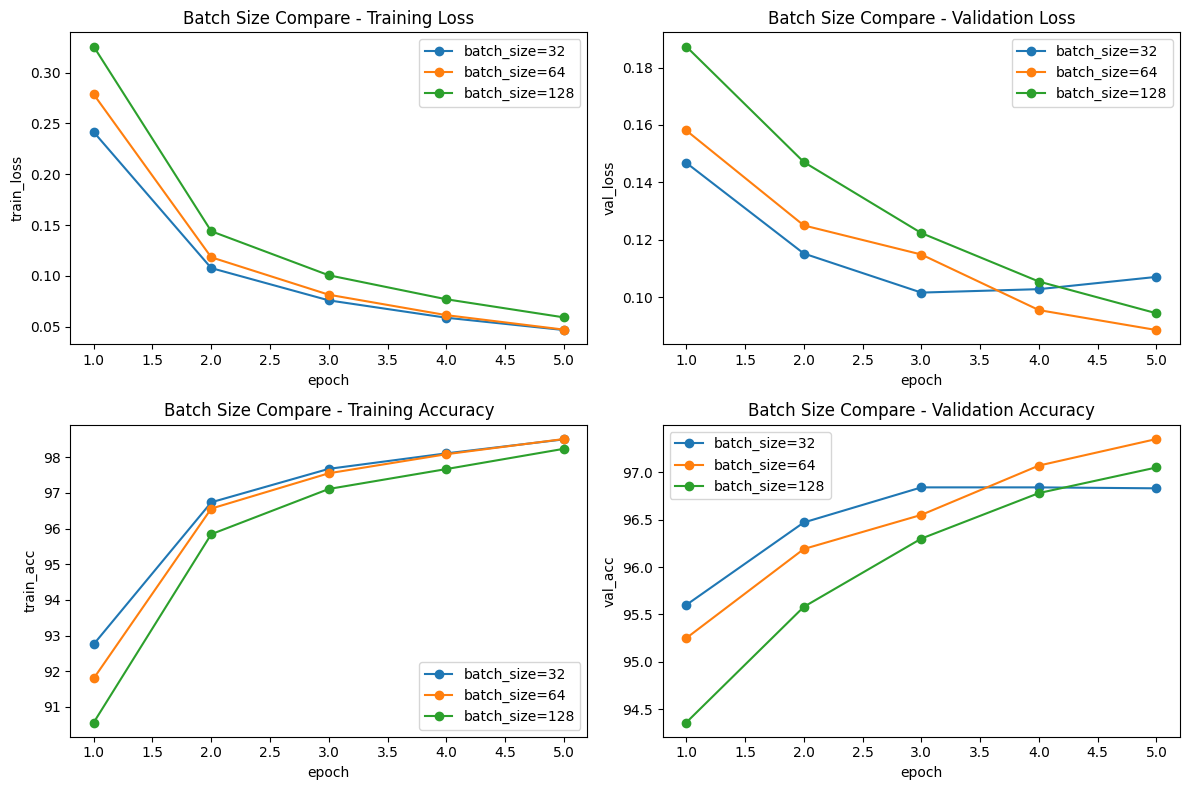

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(batch_size_histories, title_prefix="Batch Size Compare")


### 如何根据曲线分析结果？

| 情况 | 曲线表现 | 说明 | 可以怎么做 |
|---|---|---|---|
| 欠拟合 | `train_loss`、`val_loss` 都较高；<br>`train_acc`、`val_acc` 都较低 | 模型还没学好 | - 增加训练轮数<br>- 增大模型规模<br>- 调整学习率<br>- 适当减小 dropout |
| 过拟合 | `train_loss` 继续下降、`train_acc` 继续上升；<br>但 `val_loss` 上升或 `val_acc` 停止提升 | 模型对训练集学得太“死” | - 提前停止训练<br>- 增加 dropout<br>- 加入正则化<br>- 做数据增强<br>- 适当减小模型规模 |
| 可以继续训练 | `val_loss` 还在下降；<br>`val_acc` 还在上升 | 模型还有提升空间 | - 继续训练<br>- 继续观察验证集变化 |
| 可以考虑停止 | `val_loss` 不再下降；<br>`val_acc` 不再提升 | 模型基本达到当前效果上限 | - 停止训练<br>- 保留验证集表现最好的模型 |
| 比较不同参数 | `val_acc` 更高；`val_loss` 更低；<br>曲线更平稳 | 调参阶段主要看验证集表现 | - 选择验证集效果更好的参数设置 |


### 练习 2：不同网络深度对比

本实验中，“网络深度”用**隐藏层层数**表示。

建议比较：

- `[128]`：1 个隐藏层
- `[128, 128, 128]`：3 个隐藏层
- `[128, 128, 128, 128, 128]`：5 个隐藏层

其他参数保持和基线一致。  
下面只给出 1 个隐藏层的示例，请仿照补充 3 个隐藏层和 5 个隐藏层。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：1 个隐藏层
model_depth1, history_depth1, _ = run_experiment(
    exp_name="1 hidden layer",
    batch_size=64,
    hidden_dims=[128],      # 1 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories={}
depth_histories["1 hidden layer"] = history_depth1
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth1, last_n=3)



实验名称: 1 hidden layer
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5


Epoch 01/5 | train_loss=0.2786, train_acc=91.80% | val_loss=0.1581, val_acc=95.25% | time=9.31s
Epoch 02/5 | train_loss=0.1183, train_acc=96.56% | val_loss=0.1250, val_acc=96.19% | time=7.25s
Epoch 03/5 | train_loss=0.0814, train_acc=97.55% | val_loss=0.1149, val_acc=96.55% | time=5.86s
Epoch 04/5 | train_loss=0.0613, train_acc=98.08% | val_loss=0.0956, val_acc=97.07% | time=5.58s
Epoch 05/5 | train_loss=0.0471, train_acc=98.51% | val_loss=0.0886, val_acc=97.35% | time=5.46s
训练总耗时: 33.46 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.55% |   0.1149 |  96.55% |    5.86
    4 |     0.0613 |    98.08% |   0.0956 |  97.07% |    5.58
    5 |     0.0471 |    98.51% |   0.0886 |  97.35% |    5.46


In [ ]:
# TODO 1：补充 3 个隐藏层的实验。
# 示例：3 个隐藏层
model_depth3, history_depth3, _ = run_experiment(
    exp_name="3 hidden layer",
    batch_size=64,
    hidden_dims=[128, 128, 128],      # 3 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories["3 hidden layer"] = history_depth3
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth3, last_n=3)



实验名称: 3 hidden layer
batch_size: 64
hidden_dims: [128, 128, 128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2868, train_acc=91.33% | val_loss=0.1665, val_acc=94.96% | time=6.70s
Epoch 02/5 | train_loss=0.1198, train_acc=96.28% | val_loss=0.1290, val_acc=96.11% | time=6.29s
Epoch 03/5 | train_loss=0.0855, train_acc=97.35% | val_loss=0.1090, val_acc=96.69% | time=6.12s
Epoch 04/5 | train_loss=0.0658, train_acc=97.85% | val_loss=0.1009, val_acc=96.84% | time=6.99s
Epoch 05/5 | train_loss=0.0530, train_acc=98.32% | val_loss=0.1079, val_acc=97.13% | time=6.87s
训练总耗时: 32.96 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0855 |    97.35% |   0.1090 |  96.69% |    6.12
    4 |     0.0658 |    97.85% |   0.1009 |  96.84% |    6.99
    5 |     0.0530 |    98.32% |   0.1079 |  97.13% |    6.87


In [ ]:
# TODO 2：补充 5 个隐藏层的实验。
# 示例：5 个隐藏层
model_depth5, history_depth5, _ = run_experiment(
    exp_name="5 hidden layer",
    batch_size=64,
    hidden_dims=[128, 128, 128, 128, 128],      # 1 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories["5 hidden layer"] = history_depth5
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth5, last_n=3)



实验名称: 5 hidden layer
batch_size: 64
hidden_dims: [128, 128, 128, 128, 128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3528, train_acc=88.68% | val_loss=0.1780, val_acc=94.48% | time=8.97s
Epoch 02/5 | train_loss=0.1392, train_acc=95.71% | val_loss=0.1387, val_acc=95.90% | time=6.88s
Epoch 03/5 | train_loss=0.1036, train_acc=96.85% | val_loss=0.1326, val_acc=96.22% | time=7.16s
Epoch 04/5 | train_loss=0.0799, train_acc=97.59% | val_loss=0.1221, val_acc=96.60% | time=6.67s
Epoch 05/5 | train_loss=0.0675, train_acc=97.89% | val_loss=0.1197, val_acc=96.59% | time=8.08s
训练总耗时: 37.76 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1036 |    96.85% |   0.1326 |  96.22% |    7.16
    4 |     0.0799 |    97.59% |   0.1221 |  96.60% |    6.67
    5 |     0.0675 |    97.89% |   0.1197 |  96.59% |    8.08


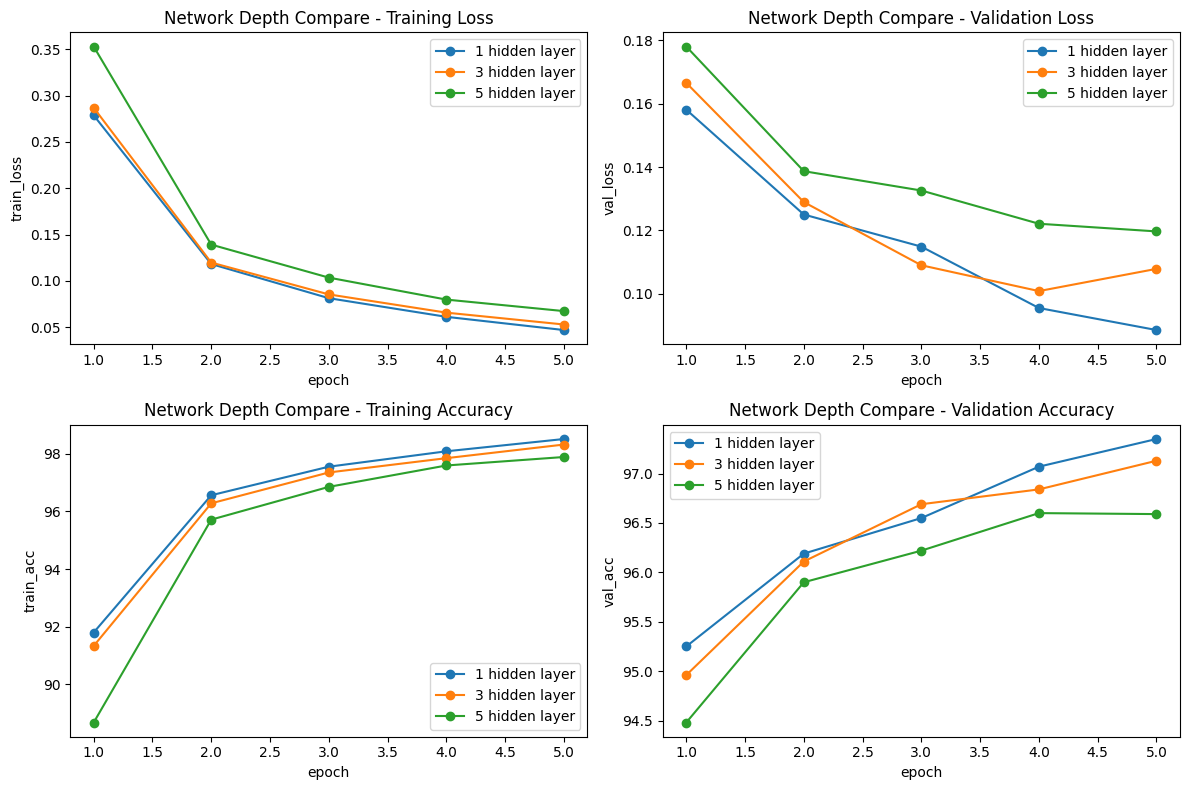

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(depth_histories, title_prefix="Network Depth Compare")


### 练习 3：不同神经元数量对比

要求比较：`64`、`128`、`256`、`512`。  
这里保持 1 个隐藏层，只改变隐藏层神经元数量。

下面只给出 `hidden_dims=[64]` 的示例，请仿照补充其他神经元数量。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：隐藏层神经元数量为 64
model_width64, history_width64, _ = run_experiment(
    exp_name="hidden_dim=64",
    batch_size=64,
    hidden_dims=[64],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories = {}
width_histories["hidden_dim=64"] = history_width64
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width64, last_n=3)



实验名称: hidden_dim=64
batch_size: 64
hidden_dims: [64]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5


Epoch 01/5 | train_loss=0.3186, train_acc=90.89% | val_loss=0.1987, val_acc=94.17% | time=6.92s
Epoch 02/5 | train_loss=0.1530, train_acc=95.44% | val_loss=0.1554, val_acc=95.12% | time=5.94s
Epoch 03/5 | train_loss=0.1110, train_acc=96.65% | val_loss=0.1271, val_acc=96.10% | time=5.42s
Epoch 04/5 | train_loss=0.0884, train_acc=97.32% | val_loss=0.1159, val_acc=96.52% | time=5.50s
Epoch 05/5 | train_loss=0.0709, train_acc=97.90% | val_loss=0.1108, val_acc=96.65% | time=5.46s
训练总耗时: 29.25 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1110 |    96.65% |   0.1271 |  96.10% |    5.42
    4 |     0.0884 |    97.32% |   0.1159 |  96.52% |    5.50
    5 |     0.0709 |    97.90% |   0.1108 |  96.65% |    5.46


In [ ]:
# TODO 1：仿照上面代码，补充 hidden_dims=[128] 的实验。
# 示例：隐藏层神经元数量为 128
model_width128, history_width128, _ = run_experiment(
    exp_name="hidden_dim=128",
    batch_size=128,
    hidden_dims=[128],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=128"] = history_width128
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width128, last_n=3)




实验名称: hidden_dim=128
batch_size: 128
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3257, train_acc=90.56% | val_loss=0.1873, val_acc=94.36% | time=8.88s
Epoch 02/5 | train_loss=0.1439, train_acc=95.84% | val_loss=0.1471, val_acc=95.58% | time=7.69s
Epoch 03/5 | train_loss=0.1006, train_acc=97.11% | val_loss=0.1224, val_acc=96.30% | time=11.03s
Epoch 04/5 | train_loss=0.0769, train_acc=97.67% | val_loss=0.1055, val_acc=96.78% | time=9.01s
Epoch 05/5 | train_loss=0.0591, train_acc=98.24% | val_loss=0.0944, val_acc=97.05% | time=15.44s
训练总耗时: 52.06 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1006 |    97.11% |   0.1224 |  96.30% |   11.03
    4 |     0.0769 |    97.67% |   0.1055 |  96.78% |    9.01
    5 |     0.0591 |    98.24% |   0.0944 |  97.05% |   15.44


In [ ]:
# TODO 2：仿照上面代码，补充 hidden_dims=[256] 的实验。
# 示例：隐藏层神经元数量为 256
model_width256, history_width256, _ = run_experiment(
    exp_name="hidden_dim=256",
    batch_size=256,
    hidden_dims=[256],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=256"] = history_width256
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width256, last_n=3)




实验名称: hidden_dim=256
batch_size: 256
hidden_dims: [256]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3488, train_acc=90.01% | val_loss=0.2028, val_acc=94.14% | time=9.99s
Epoch 02/5 | train_loss=0.1535, train_acc=95.63% | val_loss=0.1479, val_acc=95.80% | time=9.63s
Epoch 03/5 | train_loss=0.1038, train_acc=96.97% | val_loss=0.1220, val_acc=96.44% | time=9.21s
Epoch 04/5 | train_loss=0.0774, train_acc=97.75% | val_loss=0.1023, val_acc=96.83% | time=10.52s
Epoch 05/5 | train_loss=0.0592, train_acc=98.23% | val_loss=0.0964, val_acc=97.11% | time=11.31s
训练总耗时: 50.66 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1038 |    96.97% |   0.1220 |  96.44% |    9.21
    4 |     0.0774 |    97.75% |   0.1023 |  96.83% |   10.52
    5 |     0.0592 |    98.23% |   0.0964 |  97.11% |   11.31


In [ ]:
# TODO 3：仿照上面代码，补充 hidden_dims=[512] 的实验。
# 示例：隐藏层神经元数量为 512
model_width512, history_width512, _ = run_experiment(
    exp_name="hidden_dim=512",
    batch_size=512,
    hidden_dims=[512],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=512"] = history_width512
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width512, last_n=3)




实验名称: hidden_dim=512
batch_size: 512
hidden_dims: [512]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3914, train_acc=88.89% | val_loss=0.2230, val_acc=93.36% | time=6.59s
Epoch 02/5 | train_loss=0.1636, train_acc=95.36% | val_loss=0.1489, val_acc=95.52% | time=6.58s
Epoch 03/5 | train_loss=0.1091, train_acc=96.93% | val_loss=0.1206, val_acc=96.39% | time=6.55s
Epoch 04/5 | train_loss=0.0774, train_acc=97.76% | val_loss=0.1011, val_acc=96.99% | time=6.79s
Epoch 05/5 | train_loss=0.0585, train_acc=98.34% | val_loss=0.0879, val_acc=97.30% | time=5.67s
训练总耗时: 32.19 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1091 |    96.93% |   0.1206 |  96.39% |    6.55
    4 |     0.0774 |    97.76% |   0.1011 |  96.99% |    6.79
    5 |     0.0585 |    98.34% |   0.0879 |  97.30% |    5.67


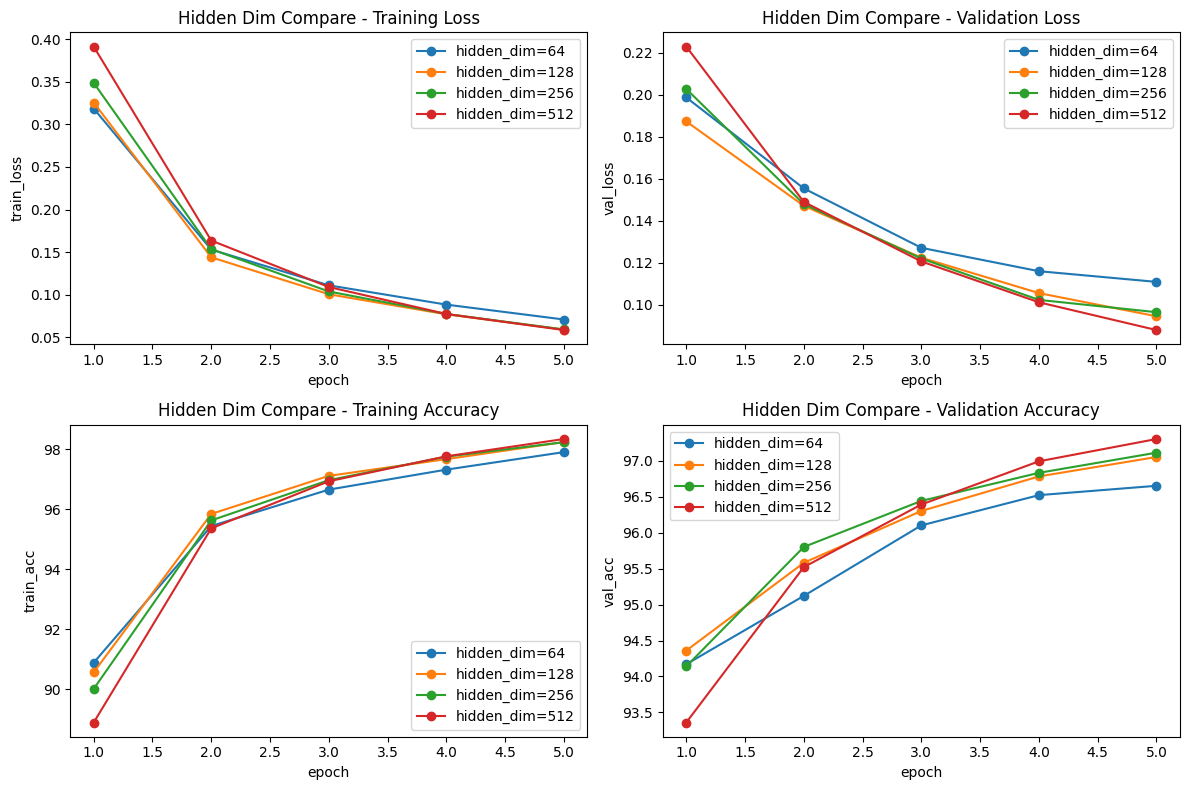

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(width_histories, title_prefix="Hidden Dim Compare")


### 练习 4：不同激活函数对比

建议比较：`relu`、`sigmoid`、`tanh`、`leaky_relu`。  
其他参数保持和基线一致。

下面只给出 `relu` 的示例，请仿照补充其他激活函数。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：激活函数为 relu
model_relu, history_relu, _ = run_experiment(
    exp_name="activation=relu",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories = {}
activation_histories["activation=relu"] = history_relu
print("\n最后 3 个 epoch 结果：")
print_history_table(history_relu, last_n=3)



实验名称: activation=relu
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5


Epoch 01/5 | train_loss=0.2786, train_acc=91.80% | val_loss=0.1581, val_acc=95.25% | time=6.75s
Epoch 02/5 | train_loss=0.1183, train_acc=96.56% | val_loss=0.1250, val_acc=96.19% | time=5.51s
Epoch 03/5 | train_loss=0.0814, train_acc=97.55% | val_loss=0.1149, val_acc=96.55% | time=5.64s
Epoch 04/5 | train_loss=0.0613, train_acc=98.08% | val_loss=0.0956, val_acc=97.07% | time=5.33s
Epoch 05/5 | train_loss=0.0471, train_acc=98.51% | val_loss=0.0886, val_acc=97.35% | time=6.02s
训练总耗时: 29.26 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.55% |   0.1149 |  96.55% |    5.64
    4 |     0.0613 |    98.08% |   0.0956 |  97.07% |    5.33
    5 |     0.0471 |    98.51% |   0.0886 |  97.35% |    6.02


In [ ]:
# TODO 1：仿照上面代码，补充 activation_name="sigmoid" 的实验。
# 示例：激活函数为sigmoid
model_sigmoid, history_sigmoid, _ = run_experiment(
    exp_name="activation=sigmoid",
    batch_size=64,
    hidden_dims=[128],
    activation_name="sigmoid",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=sigmoid"] = history_sigmoid
print("\n最后 3 个 epoch 结果：")
print_history_table(history_sigmoid, last_n=3)




实验名称: activation=sigmoid
batch_size: 64
hidden_dims: [128]
activation_name: sigmoid
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.4314, train_acc=89.02% | val_loss=0.2515, val_acc=92.68% | time=6.20s
Epoch 02/5 | train_loss=0.1965, train_acc=94.39% | val_loss=0.1939, val_acc=94.34% | time=5.42s
Epoch 03/5 | train_loss=0.1449, train_acc=95.93% | val_loss=0.1612, val_acc=95.21% | time=6.38s
Epoch 04/5 | train_loss=0.1133, train_acc=96.90% | val_loss=0.1390, val_acc=95.96% | time=6.37s
Epoch 05/5 | train_loss=0.0907, train_acc=97.52% | val_loss=0.1261, val_acc=96.19% | time=5.42s
训练总耗时: 29.79 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1449 |    95.93% |   0.1612 |  95.21% |    6.38
    4 |     0.1133 |    96.90% |   0.1390 |  95.96% |    6.37
    5 |     0.0907 |    97.52% |   0.1261 |  96.19% |    5.42


In [ ]:
# TODO 2：仿照上面代码，补充 activation_name="tanh" 的实验。
# 示例：激活函数为 relu
model_tanh, history_tanh, _ = run_experiment(
    exp_name="activation=tanh",
    batch_size=64,
    hidden_dims=[128],
    activation_name="tanh",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=tanh"] = history_tanh
print("\n最后 3 个 epoch 结果：")
print_history_table(history_tanh, last_n=3)




实验名称: activation=tanh
batch_size: 64
hidden_dims: [128]
activation_name: tanh
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2960, train_acc=91.58% | val_loss=0.1907, val_acc=94.34% | time=5.97s
Epoch 02/5 | train_loss=0.1411, train_acc=95.94% | val_loss=0.1491, val_acc=95.65% | time=5.30s
Epoch 03/5 | train_loss=0.0993, train_acc=97.22% | val_loss=0.1262, val_acc=96.16% | time=5.92s
Epoch 04/5 | train_loss=0.0765, train_acc=97.83% | val_loss=0.1194, val_acc=96.40% | time=8.66s
Epoch 05/5 | train_loss=0.0589, train_acc=98.38% | val_loss=0.1127, val_acc=96.44% | time=5.96s
训练总耗时: 31.81 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0993 |    97.22% |   0.1262 |  96.16% |    5.92
    4 |     0.0765 |    97.83% |   0.1194 |  96.40% |    8.66
    5 |     0.0589 |    98.38% |   0.1127 |  96.44% |    5.96


In [ ]:
# TODO 3：仿照上面代码，补充 activation_name="leaky_relu" 的实验。
# 示例：激活函数为 relu
model_leaky_relu, history_leaky_relu, _ = run_experiment(
    exp_name="activation=leaky_relu",
    batch_size=64,
    hidden_dims=[128],
    activation_name="leaky_relu",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=leaky_relu"] = history_leaky_relu
print("\n最后 3 个 epoch 结果：")
print_history_table(history_leaky_relu, last_n=3)




实验名称: activation=leaky_relu
batch_size: 64
hidden_dims: [128]
activation_name: leaky_relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2807, train_acc=91.70% | val_loss=0.1647, val_acc=95.05% | time=7.19s
Epoch 02/5 | train_loss=0.1212, train_acc=96.45% | val_loss=0.1258, val_acc=96.30% | time=5.72s
Epoch 03/5 | train_loss=0.0836, train_acc=97.42% | val_loss=0.1181, val_acc=96.47% | time=6.57s
Epoch 04/5 | train_loss=0.0635, train_acc=98.01% | val_loss=0.0975, val_acc=97.11% | time=7.87s
Epoch 05/5 | train_loss=0.0495, train_acc=98.47% | val_loss=0.0926, val_acc=97.30% | time=8.55s
训练总耗时: 35.89 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0836 |    97.42% |   0.1181 |  96.47% |    6.57
    4 |     0.0635 |    98.01% |   0.0975 |  97.11% |    7.87
    5 |     0.0495 |    98.47% |   0.0926 |  97.30% |    8.55


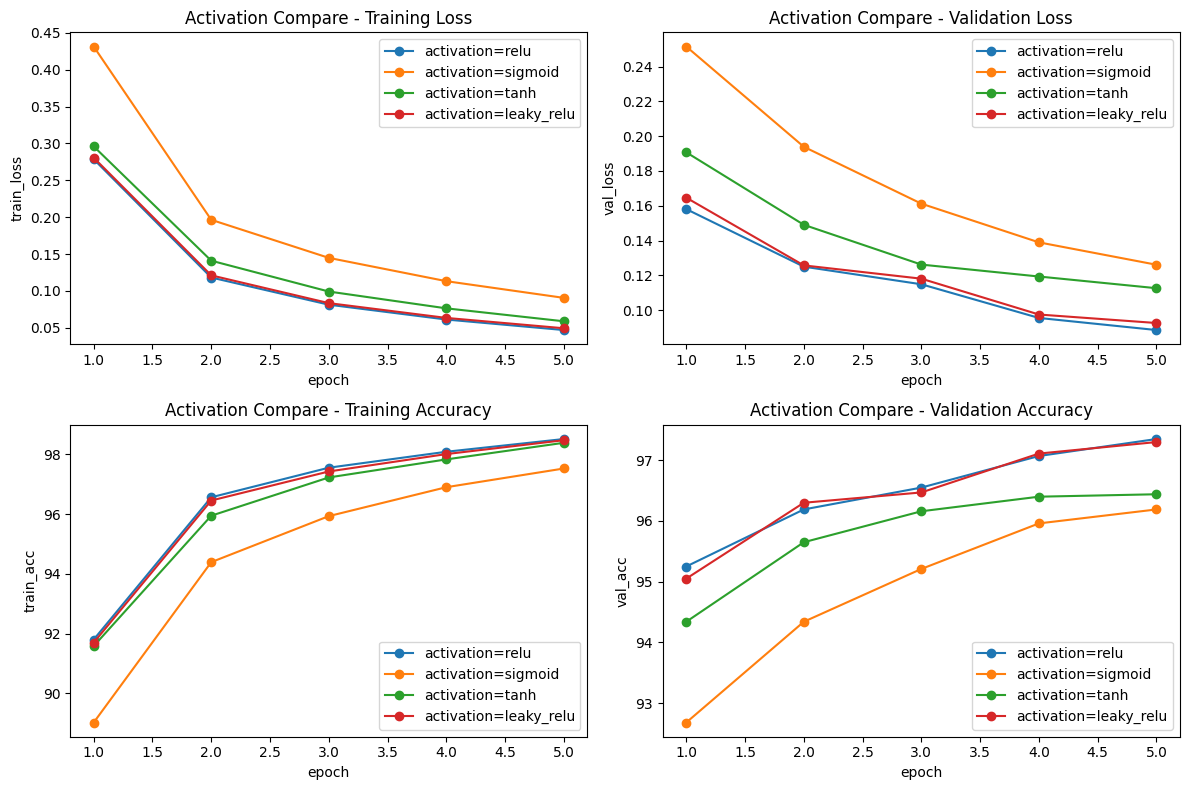

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(activation_histories, title_prefix="Activation Compare")


### 练习 5：Dropout 对比

建议比较：无 Dropout、`p=0.2`、`p=0.5`。  
观察训练集与验证集之间的差距，分析是否出现过拟合。

下面只给出无 Dropout 的示例，请仿照补充 `p=0.2` 和 `p=0.5`。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线，并重点关注 `train-val` 的差距。


In [ ]:
# 示例：无 Dropout
model_dropout0, history_dropout0, _ = run_experiment(
    exp_name="dropout_p=0.0",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories = {}
dropout_histories["dropout_p=0.0"] = history_dropout0
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout0, last_n=3)


实验名称: dropout_p=0.0
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2786, train_acc=91.80% | val_loss=0.1581, val_acc=95.25% | time=6.85s
Epoch 02/5 | train_loss=0.1183, train_acc=96.56% | val_loss=0.1250, val_acc=96.19% | time=6.93s
Epoch 03/5 | train_loss=0.0814, train_acc=97.55% | val_loss=0.1149, val_acc=96.55% | time=7.02s
Epoch 04/5 | train_loss=0.0613, train_acc=98.08% | val_loss=0.0956, val_acc=97.07% | time=9.86s
Epoch 05/5 | train_loss=0.0471, train_acc=98.51% | val_loss=0.0886, val_acc=97.35% | time=6.86s
训练总耗时: 37.52 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.55% |   0.1149 |  96.55% |    7.02
    4 |     0.0613 |    98.08% |   0.0956 |  97.07% |    9.86
    5 |     0.0471 |    98.51% |   0.0886 |  97.35% |    6.86


In [ ]:
# TODO 1：仿照上面代码，补充 dropout_p=0.2 的实验。
# 示例：dropout_p=0.2
model_dropout2, history_dropout2, _ = run_experiment(
    exp_name="dropout_p=0.2",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.2,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories["dropout_p=0.2"] = history_dropout2
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout2, last_n=3)


实验名称: dropout_p=0.2
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.2
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3115, train_acc=90.70% | val_loss=0.1654, val_acc=95.00% | time=6.24s
Epoch 02/5 | train_loss=0.1497, train_acc=95.54% | val_loss=0.1215, val_acc=96.40% | time=6.18s
Epoch 03/5 | train_loss=0.1171, train_acc=96.47% | val_loss=0.1122, val_acc=96.70% | time=5.43s
Epoch 04/5 | train_loss=0.0956, train_acc=97.01% | val_loss=0.0968, val_acc=97.07% | time=12.77s
Epoch 05/5 | train_loss=0.0845, train_acc=97.35% | val_loss=0.0905, val_acc=97.23% | time=12.30s
训练总耗时: 42.91 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1171 |    96.47% |   0.1122 |  96.70% |    5.43
    4 |     0.0956 |    97.01% |   0.0968 |  97.07% |   12.77
    5 |     0.0845 |    97.35% |   0.0905 |  97.23% |   12.30


In [ ]:
# TODO 2：仿照上面代码，补充 dropout_p=0.5 的实验。
# 示例：无 Dropout
model_dropout5, history_dropout5, _ = run_experiment(
    exp_name="dropout_p=0.5",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.5,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories["dropout_p=0.5"] = history_dropout5
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout5, last_n=3)


实验名称: dropout_p=0.5
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.5
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.4058, train_acc=87.76% | val_loss=0.1977, val_acc=94.12% | time=23.42s
Epoch 02/5 | train_loss=0.2384, train_acc=92.87% | val_loss=0.1528, val_acc=95.69% | time=6.05s
Epoch 03/5 | train_loss=0.2030, train_acc=93.95% | val_loss=0.1306, val_acc=96.24% | time=6.44s
Epoch 04/5 | train_loss=0.1808, train_acc=94.39% | val_loss=0.1161, val_acc=96.58% | time=7.45s
Epoch 05/5 | train_loss=0.1652, train_acc=94.98% | val_loss=0.1144, val_acc=96.59% | time=6.41s
训练总耗时: 49.77 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.2030 |    93.95% |   0.1306 |  96.24% |    6.44
    4 |     0.1808 |    94.39% |   0.1161 |  96.58% |    7.45
    5 |     0.1652 |    94.98% |   0.1144 |  96.59% |    6.41


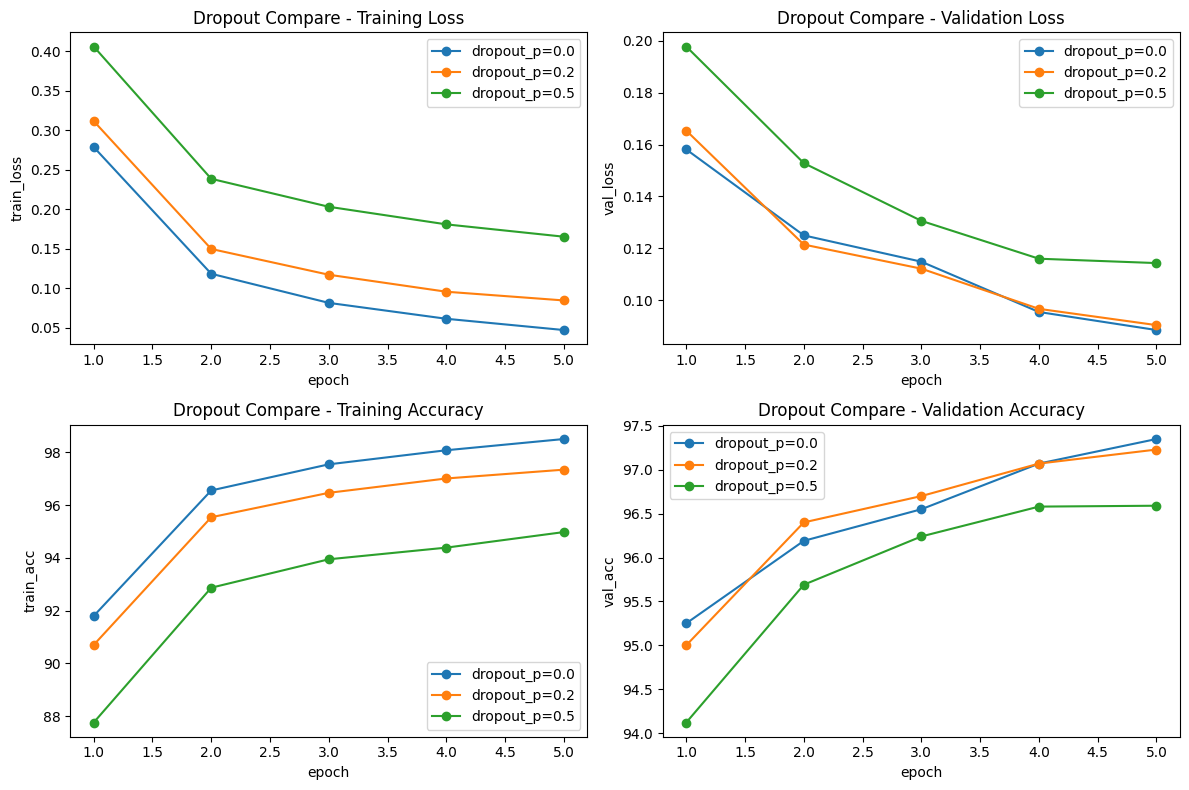

In [ ]:
# 统一绘制 4 张曲线（2×2 子图），并结合 train-val 差距分析是否过拟合。
plot_compare_grid(dropout_histories, title_prefix="Dropout Compare")


### 练习 6：不同调参方向的最佳单变量结果对比

在每一类单变量实验中，请根据验证集结果选出该类表现最好的设置。

例如：
- batch size 中选出最优的一个
- 网络深度中选出最优的一个
- 神经元数量中选出最优的一个
- 激活函数中选出最优的一个
- Dropout 中选出最优的一个

然后将这些“最佳单变量结果”放在一起绘制对比曲线，比较不同调参方向对模型性能的影响。

建议继续绘制：
- 训练损失曲线
- 验证损失曲线
- 训练准确率曲线
- 验证准确率曲线

**说明：若不同调参方向的最佳设置恰好相同，或者某个方向的最佳设置与基线相同，部分曲线可能重合，这是正常现象。** 


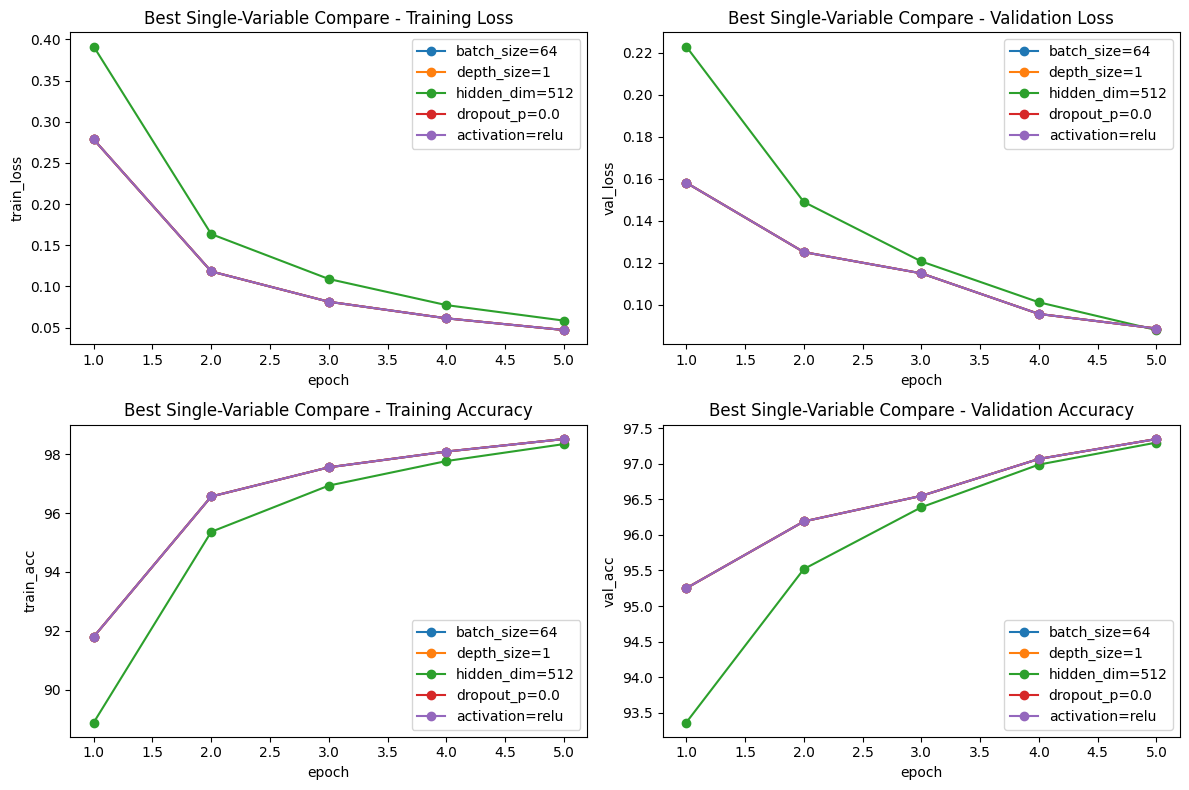

In [ ]:
# TODO：将你已经完成的实验 history 放入 histories 字典中，然后绘图。
# 例如，如果你完成了 batch_size / depth / width / activation / dropout 五类实验，
# 就把每一类“验证集表现最好的那一组” history 放进来。

histories = {
    # TODO ：请按你自己实验中“每个调参方向的最佳单变量结果”修改下面的标签和 history 变量。
    "batch_size=64": history_bs64,
    "depth_size=1": history_depth1,
    "hidden_dim=512" : history_width512,
    "dropout_p=0.0" : history_dropout0,
    "activation=relu" : history_relu,
}

plot_compare_grid(histories, title_prefix="Best Single-Variable Compare")  


### 思考与分析

完成本练习后，可以思考下面几个问题：

- 不同调参方向中，哪一类改动对模型性能影响最明显？
- 收敛速度更快的模型，最终验证效果是否一定更好？
- 训练集准确率更高，是否一定代表模型泛化能力更强？

### 最终测试

完成调参后，选择验证集表现较好的模型，在测试集上评估一次。  
把最终测试准确率写入实验报告。


In [ ]:
# TODO : 请把下面参数改成你最终选择的模型设置。
final_model, final_history, final_test_loader = run_experiment(
    exp_name="final_model",
    batch_size=64,
    hidden_dims=[64],
    activation_name="relu",
    dropout_p=0.2,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)

criterion = nn.CrossEntropyLoss()
final_test_loss, final_test_acc = evaluate(final_model, final_test_loader, criterion)

print("\n最终模型最后 3 个 epoch 结果：")
print_history_table(final_history, last_n=3)

print(f"Final test loss: {final_test_loss:.4f}")
print(f"Final test accuracy: {final_test_acc:.2f}%")


NameError: name 'run_experiment' is not defined

## 四、附加题（选做）



### 附加题 1：联合调参探索

要求：在前面单变量调参实验的基础上，**同时调整多个参数**，设计新的模型配置，并与基线模型或单变量实验结果进行对比。

提示：
- 可尝试组合各类实验中表现较好的参数设置；
- 例如同时调整 batch size、网络深度、神经元数量、激活函数、Dropout 等。

注意：
- 前面选出的“最佳单变量结果”，是在其他参数保持基线不变的前提下得到的。
- 因此，各类实验中分别选出的最佳设置，直接组合后不一定仍然是最优模型；有时效果可能更好，也可能变差。
- 本题重在观察联合调参后的效果变化，并做简要分析。

In [ ]:
# TODO：选做。
# 尝试联合调参：同时修改多个参数，设计新的模型配置。

# 假设你之前单变量实验得到的“可能表现较好”的参数池如下：
# - 网络结构：更深更宽 [256, 128]
# - 激活函数：relu 或 leaky_relu
# - Dropout：0.2 或 0.3 (因为网络变深了，需要防止过拟合)
# - Batch Size：32 (更快的收敛)
# - 学习率：0.0005 (网络变复杂了，稍微降低学习率让训练更平稳)

print("==== 开始联合调参实验 ====")

model_joint, history_joint, _ = run_experiment(
    exp_name="Joint_Tuning_Combined",
    batch_size=32,                  # 【调整】
    hidden_dims=[256, 128],         # 【调整】增加深度和宽度
    activation_name="relu",         # 【调整】
    dropout_p=0.2,                  # 【调整】加入正则化
    learning_rate=0.0005,           # 【调整】配合更深的网络降低LR
    epochs=10,                      # 可以适当增加 epoch 观察完整收敛过程
    verbose=True,
)

# 准备对比字典 (假设你之前跑过了 baseline_history)
# 注意：确保 baseline_history 变量在你的环境中是存在的
joint_compare_histories = {
    "1. Baseline": history_baseline,      # 填入你最初的基线结果
    "2. Joint Tuning": history_joint      # 填入本次联合调参的结果
}

# 打印表格对比
print("\n[联合调参模型] 最后 3 个 epoch 结果：")
print_history_table(history_joint, last_n=3)

# 绘制曲线对比图
plot_compare_grid(joint_compare_histories, title_prefix="Joint Tuning vs Baseline")

==== 开始联合调参实验 ====
实验名称: Joint_Tuning_Combined
batch_size: 32
hidden_dims: [256, 128]
activation_name: relu
dropout_p: 0.2
learning_rate: 0.0005
epochs: 10
Epoch 01/10 | train_loss=0.3138, train_acc=90.59% | val_loss=0.1522, val_acc=95.21% | time=11.88s
Epoch 02/10 | train_loss=0.1383, train_acc=95.82% | val_loss=0.1086, val_acc=96.72% | time=12.13s
Epoch 03/10 | train_loss=0.1027, train_acc=96.85% | val_loss=0.0979, val_acc=96.94% | time=9.75s
Epoch 04/10 | train_loss=0.0840, train_acc=97.33% | val_loss=0.0936, val_acc=97.27% | time=8.41s
Epoch 05/10 | train_loss=0.0700, train_acc=97.86% | val_loss=0.0840, val_acc=97.45% | time=9.19s
Epoch 06/10 | train_loss=0.0599, train_acc=98.10% | val_loss=0.0871, val_acc=97.46% | time=8.28s
Epoch 07/10 | train_loss=0.0537, train_acc=98.26% | val_loss=0.0887, val_acc=97.44% | time=8.66s
Epoch 08/10 | train_loss=0.0480, train_acc=98.40% | val_loss=0.0885, val_acc=97.61% | time=8.36s
Epoch 09/10 | train_loss=0.0458, train_acc=98.54% | val_loss=0.086

NameError: name 'history_baseline' is not defined

### 附加题 2：数据增强

要求：只**对训练集使用数据增强**，验证集和测试集不要使用随机增强。

因为验证/测试阶段需要使用稳定、可重复的数据来客观评估模型性能。

可以尝试：

- `transforms.RandomRotation(...)`
- `transforms.RandomCrop(...)`
- 其他合理的图像增强方法

观察增强前后验证集或测试集准确率的变化。


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 1. 数据准备 (Data Augmentation) ---
# 定义训练集 Transforms (带增强)
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(size=28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 定义验证集 Transforms (无增强，仅标准化)
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加载数据集
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transforms)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# --- 2. 模型与训练设置 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 假设你已经定义好了 MNIST_CNN
model = MNIST_CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5 
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# --- 3. 训练与验证循环 ---
print("==== Start Training ====")
for epoch in range(epochs):
    # --- 训练阶段 ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train
    
    # --- 验证阶段 ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("==== Training Finished ====")

Using device: cpu
==== Start Training ====
Epoch [1/5] Train Loss: 0.3099, Train Acc: 90.21% | Val Loss: 0.0464, Val Acc: 98.49%
Epoch [2/5] Train Loss: 0.1397, Train Acc: 95.67% | Val Loss: 0.0417, Val Acc: 98.69%
Epoch [3/5] Train Loss: 0.1223, Train Acc: 96.34% | Val Loss: 0.0283, Val Acc: 99.08%
Epoch [4/5] Train Loss: 0.1090, Train Acc: 96.59% | Val Loss: 0.0353, Val Acc: 98.78%
Epoch [5/5] Train Loss: 0.1000, Train Acc: 96.99% | Val Loss: 0.0256, Val Acc: 99.20%
==== Training Finished ====


### 附加题 3：自定义网络结构

要求：设计一个**不同于基础全连接 BP 网络的模型**，并与基线模型对比。

可以任选一种方向：

- 加入 BatchNorm
- 加入卷积层 Conv2d 和池化层 MaxPool2d
- 设计更深或更宽的网络
- 尝试残差连接等拓展结构

注意：不要求全部实现，任选一种合理扩展即可。


In [ ]:
# TODO：选做。
# 自定义一个不同于基础全连接 BP 网络的模型，并比较验证集/测试集表现。
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MNIST_CNN, self).__init__()
        
        # --- 第一个卷积块 ---
        # 输入尺寸: [batch_size, 1, 28, 28]  <-- 注意这里 in_channels=1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        # 经过 pool1 后，图片尺寸减半，变为: [batch_size, 16, 14, 14]

        # --- 第二个卷积块 ---
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 经过 pool2 后，尺寸再次减半，变为: [batch_size, 32, 7, 7]

        # --- 全连接层 ---
        # 【关键修改】展平后的特征总数 = 通道数(32) * 高(7) * 宽(7) = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # 卷积 -> BN -> 激活 -> 池化
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        # 展平特征图，准备送入全连接层
        x = x.view(x.size(0), -1) 

        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. 基础设置 ---
# 检查是否有 GPU，如果有就用 GPU 加速，否则用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用设备: {device}")

# 实例化我们刚才定义的 CNN 模型并移动到设备上
model = MNIST_CNN(num_classes=10).to(device)

# 定义交叉熵损失函数 (用于多分类任务)
criterion = nn.CrossEntropyLoss()

# 定义 Adam 优化器 (相比传统 SGD 收敛更快)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 定义要训练的轮数
epochs = 5 

# 用一个字典来保存每轮的训练数据，方便后面画图
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# --- 2. 训练与验证循环 ---
# 注意：假设你已经准备好了 train_loader 和 val_loader
print("==== 开始训练 ====")
for epoch in range(epochs):
    
    # ---------------- 训练阶段 ----------------
    model.train() # 设置为训练模式 (启用 Dropout 和 BatchNorm)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 梯度清零
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播与参数更新
        loss.backward()
        optimizer.step()
        
        # 统计训练 loss 和准确率
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train
    
    # ---------------- 验证阶段 ----------------
    model.eval() # 设置为评估模式 (关闭 Dropout，冻结 BatchNorm 参数)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # 验证阶段不需要计算梯度，可以节省显存和加速
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val
    
    # ---------------- 保存并打印当前 Epoch 结果 ----------------
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("==== 训练结束 ====")

正在使用设备: cpu
==== 开始训练 ====
Epoch [1/5] Train Loss: 0.1744, Train Acc: 94.71% | Val Loss: 0.0655, Val Acc: 98.09%
Epoch [2/5] Train Loss: 0.0684, Train Acc: 97.93% | Val Loss: 0.0454, Val Acc: 98.67%
Epoch [3/5] Train Loss: 0.0535, Train Acc: 98.34% | Val Loss: 0.0512, Val Acc: 98.47%
Epoch [4/5] Train Loss: 0.0447, Train Acc: 98.62% | Val Loss: 0.0386, Val Acc: 98.88%
Epoch [5/5] Train Loss: 0.0376, Train Acc: 98.82% | Val Loss: 0.0356, Val Acc: 98.85%
==== 训练结束 ====


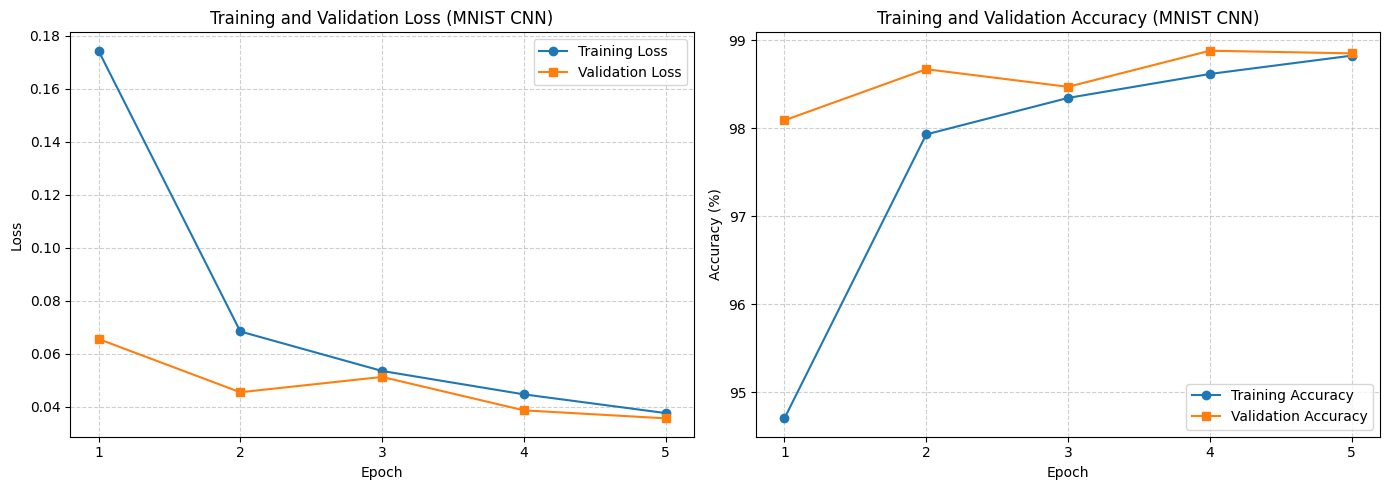

In [ ]:
# --- 3. 绘制训练过程曲线 ---
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# 绘制 Loss 对比图 (左图)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training and Validation Loss (MNIST CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 Accuracy 对比图 (右图)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy (MNIST CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# 附加题：尝试不同的优化器
from torch.optim import SGD, RMSprop

# 定义一个函数来测试不同优化器的性能
def test_optimizer(optimizer_class, optimizer_name):
    model = MNIST_CNN().to(device)
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"{optimizer_name} - Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

# 测试不同的优化器
sgd_history = test_optimizer(SGD, "SGD")
rmsprop_history = test_optimizer(RMSprop, "RMSprop")

: 